In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator, NullFormatter
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 7,
        "figure.dpi": 200,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
    }
)

In [2]:
import json
import subprocess
import textwrap


def run_r_fisher_test(a, b, c, d, alternative="two.sided", conf_level=0.95):
    """
    Run R's fisher.test() on a 2x2 table and return parsed results.

    Parameters
    ----------
    a, b, c, d : int
        2x2 contingency table values:
            [[a, b],
             [c, d]]
    alternative : {"two.sided", "greater", "less"}
        Alternative hypothesis for fisher.test().
    conf_level : float
        Confidence level for the odds ratio CI.

    Returns
    -------
    dict
        {
            "p_value": float,
            "odds_ratio": float,
            "ci_low": float,
            "ci_high": float,
            "alternative": str,
            "conf_level": float,
            "table": [[a, b], [c, d]]
        }
    """
    valid_alternatives = {"two.sided", "greater", "less"}
    if alternative not in valid_alternatives:
        raise ValueError(f"alternative must be one of {valid_alternatives}")
    if not (0 < conf_level < 1):
        raise ValueError("conf_level must be between 0 and 1")

    # force integers
    a, b, c, d = map(int, (a, b, c, d))

    r_code = textwrap.dedent(
        f"""
        options(warn = 1)

        tab <- matrix(c({a}, {b}, {c}, {d}), nrow = 2, byrow = TRUE)
        res <- fisher.test(
            tab,
            alternative = "{alternative}",
            conf.int = TRUE,
            conf.level = {conf_level}
        )

        out <- list(
            p_value = unname(res$p.value),
            odds_ratio = unname(res$estimate),
            ci_low = unname(res$conf.int[1]),
            ci_high = unname(res$conf.int[2]),
            alternative = "{alternative}",
            conf_level = {conf_level}
        )

        cat(jsonlite::toJSON(out, auto_unbox = TRUE, digits = NA))
    """
    )

    try:
        result = subprocess.run(
            ["Rscript", "-e", r_code], capture_output=True, text=True, check=True
        )
    except FileNotFoundError:
        raise RuntimeError(
            "Rscript not found. Please make sure R is installed and Rscript is in PATH."
        )
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            f"R fisher.test failed.\nSTDOUT:\n{e.stdout}\nSTDERR:\n{e.stderr}"
        ) from e

    try:
        parsed = json.loads(result.stdout)
    except json.JSONDecodeError as e:
        raise RuntimeError(
            f"Failed to parse R output as JSON.\nRaw output:\n{result.stdout}\nSTDERR:\n{result.stderr}"
        ) from e

    parsed["table"] = [[a, b], [c, d]]
    return parsed

In [3]:
# Read data
df = pd.read_csv("data/RDH_all_possible_mis_syn_mutation_annotated.tsv", sep="\t")

In [4]:
# Conduct Fisher's exact test
DNM_COL = "DD DNM count"
control_col = "is in gnomAD NFE"
rows = []

for family in df["gene family"].unique():

    tmp = df[df["gene family"] == family]
    mis_df = tmp[tmp["consequence"] == "nonsynonymous SNV"].copy()
    syn_df = tmp[tmp["consequence"] == "synonymous SNV"].copy()

    syn_DNM = syn_df[DNM_COL].sum()
    syn_ctrl = syn_df[control_col].sum()

    def fisher_summary(mis_DNM, mis_ctrl):
        return run_r_fisher_test(mis_DNM, mis_ctrl, syn_DNM, syn_ctrl)

    mis_df["bin"] = pd.qcut(mis_df["HistMTR"], q=2, labels=False, duplicates="drop")

    for bin_id, sub_df in mis_df.groupby("bin"):

        mis_DNM = sub_df[DNM_COL].sum()
        mis_ctrl = sub_df[control_col].sum()
        result = fisher_summary(mis_DNM, mis_ctrl)
        threshold = sub_df["HistMTR"].max()
        rows.append(
            {
                "family": family,
                "bin": int(bin_id) + 1,
                "threshold": threshold,
                "DD.mis": mis_DNM,
                "DD.syn": syn_DNM,
                "gnomAD_low_freq.mis": mis_ctrl,
                "gnomAD_low_freq.syn": syn_ctrl,
                **result,
            }
        )

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values(["family", "bin"]).reset_index(drop=True)
result_df["log2OR"] = np.log2(result_df["odds_ratio"])

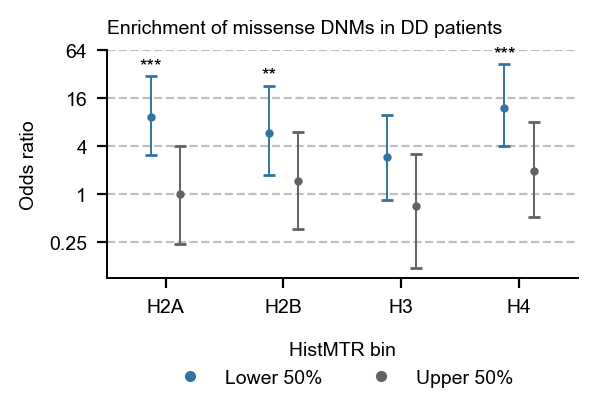

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(3, 2.2))

x_column = "family"
hue_column = "bin"

category_order = (
    result_df[result_df[x_column] == "H2A"]
    .sort_values("odds_ratio", ascending=False)[hue_column]
    .tolist()
)

or_mat = result_df.pivot(index=x_column, columns=hue_column, values="odds_ratio").loc[
    :, category_order
]
low_mat = result_df.pivot(index=x_column, columns=hue_column, values="ci_low").loc[
    :, category_order
]
high_mat = result_df.pivot(index=x_column, columns=hue_column, values="ci_high").loc[
    :, category_order
]
p_mat = result_df.pivot(index=x_column, columns=hue_column, values="p_value").loc[
    :, category_order
]

bins = sorted(result_df[x_column].unique())
x = np.arange(len(bins))

n_hue = len(category_order)
group_width = 0.5
inner_gap = 0
bar_width = group_width / (n_hue + inner_gap * (n_hue - 1))


def get_significance(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


category_colors = {1: "#3274a1", 2: "#626262"}

for i, category in enumerate(category_order):

    xpos = (
        x - group_width / 2 + bar_width / 2 + i * bar_width + i * inner_gap * bar_width
    )

    y = or_mat[category].to_numpy()
    yerr = np.vstack(
        [y - low_mat[category].to_numpy(), high_mat[category].to_numpy() - y]
    )

    ax.errorbar(
        xpos,
        y,
        yerr=yerr,
        fmt="o",
        color=category_colors[category],
        ecolor=category_colors[category],
        elinewidth=0.7,
        capsize=2,
        markersize=2,
        zorder=3,
    )

    # significance
    offset = 0.02 * (
        ax.get_ylim()[1] - ax.get_ylim()[0]
        if ax.get_ylim()[1] > ax.get_ylim()[0]
        else 1
    )
    for xi, hi, p in zip(
        xpos, high_mat[category].to_numpy(), p_mat[category].to_numpy()
    ):
        sig = get_significance(p)
        if sig:
            ax.text(xi, hi + offset, sig, ha="center", va="bottom", fontsize=7)

# grid
ax.grid(True, linestyle="--", alpha=0.5, color="gray", zorder=0, axis="y")
ax.set_title("Enrichment of missense DNMs in DD patients", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Odds ratio")
ax.spines[["top", "right"]].set_visible(False)

# x tick labels
xlabels = ["H2A", "H2B", "H3", "H4"]
ax.set_xticks(list(range(0, 4)))
ax.set_xticklabels(xlabels)

# baseline
ax.set_yscale("log")
yticks = [0.25, 1, 4, 16, 64]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticklabels(f"{i}" for i in yticks)
ax.set_xlim(-0.5, 3.5)
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color=category_colors[1],
        markerfacecolor=category_colors[1],
        markeredgecolor=category_colors[1],
        markersize=3,
        label="Lower 50%",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color=category_colors[2],
        markerfacecolor=category_colors[2],
        markeredgecolor=category_colors[2],
        markersize=3,
        label="Upper 50%",
    ),
]

ax.legend(
    handles=legend_handles,
    title="HistMTR bin",
    frameon=False,
    loc="upper center",
    fontsize=7,
    title_fontsize=7,
    bbox_to_anchor=(0.5, -0.2),
    ncols=2,
)
plt.tight_layout()